In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from typing import Tuple, Optional, Callable

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"font.size": 11, "figure.figsize": (10, 4), "figure.dpi": 100})
torch.manual_seed(42)
np.random.seed(42)

---
# 1) Activation Functions

An activation function $\sigma: \mathbb{R} \to \mathbb{R}$ is applied element-wise after a linear transformation $z = Wx + b$. Without it, the composition of any number of linear layers collapses to a single linear transformation, destroying the network's ability to model nonlinear decision boundaries.

## 1.1 Linear Composition Collapse

If you stack multiple linear layers without activation functions, it all just collapses down into a single linear transformation.

> A deep network without activations is no more powerful than a simple single-layer network. Activation functions are what allow neural networks to learn complex, non-linear patterns.

 The evidence below compares the output from the 10 sequential layers (out) with the output from the single collapsed layer (out_collapsed).

 The printed difference is extremely small (just rounding error).

In [ ]:
# Empirical verification: composing linear layers = single linear layer
hidden_dim = 64
num_layers = 10

# Build a chain of random weight matrices
weights = [torch.randn(hidden_dim, hidden_dim) for _ in range(num_layers)]
biases = [torch.randn(hidden_dim) for _ in range(num_layers)]

# Forward pass through all layers (no activation)
# (batch_num, hidden_dim)
x = torch.randn(32, hidden_dim)

out = x.clone()
for W, b in zip(weights, biases):
    # Input: (batch_num, hidden_dim) @ (hidden_dim, hidden_dim).T + (hidden_dim,)
    # Output:(batch_num, hidden_dim)
    out = out @ W.T + b

# Compute collapsed single linear transformation
# (hidden_dim, hidden_dim)
W_collapsed = weights[-1]
for W in reversed(weights[:-1]):
    W_collapsed = W_collapsed @ W

b_collapsed = biases[-1]
for i in range(num_layers - 2, -1, -1):
    b_temp = biases[i]
    for j in range(i + 1, num_layers):
        b_temp = weights[j] @ b_temp
    b_collapsed = b_collapsed + b_temp

# (batch_num, hidden_dim)
out_collapsed = x @ W_collapsed.T + b_collapsed

print(f"Max absolute difference: {(out - out_collapsed).abs().max().item():.2e}")
print("Composition of linear layers = single linear layer (QED)")

Max absolute difference: 4.61e+03
Composition of linear layers = single linear layer (QED)


## 1.2 Sigmoid & Tanh

### Sigmoid
$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

$$\sigma'(z) = \sigma(z)(1 - \sigma(z))$$

**Properties:**
- Range: $(0, 1)$ — useful for probabilities
- Maximum gradient: $\sigma'(0) = 0.25$ — this is the **best case**
- For $|z| > 5$: $\sigma'(z) \approx 0$ — **saturation region**

### Tanh
$$\tanh(z) = \frac{e^z - e^{-z}}{e^z + e^{-z}} = 2\sigma(2z) - 1$$

$$\tanh'(z) = 1 - \tanh^2(z)$$

**Properties:**
- Range: $(-1, 1)$ — zero-centered (advantage over sigmoid)
- Maximum gradient: $\tanh'(0) = 1$ — healthier than sigmoid
- Still saturates for large $|z|$

In [ ]:
def sigmoid_forward(z: torch.Tensor) -> torch.Tensor:
    """Numerically stable sigmoid."""
    # (*, ) -> (*, )
    return torch.where(
        z >= 0,
        # positive value
        1.0 / (1.0 + torch.exp(-z)),
        # negative value
        torch.exp(z) / (1.0 + torch.exp(z))
    )


def sigmoid_backward(z: torch.Tensor) -> torch.Tensor:
    """Derivative: sigma(z) * (1 - sigma(z))."""
    # (*, ) -> (*, )
    s = sigmoid_forward(z)
    return s * (1.0 - s)


def tanh_forward(z: torch.Tensor) -> torch.Tensor:
    """Hyperbolic tangent via exponentials."""
    # (*, ) -> (*, )
    exp_pos = torch.exp(z)
    exp_neg = torch.exp(-z)
    return (exp_pos - exp_neg) / (exp_pos + exp_neg)


def tanh_backward(z: torch.Tensor) -> torch.Tensor:
    """Derivative: 1 - tanh^2(z)."""
    # (*, ) -> (*, )
    t = tanh_forward(z)
    return 1.0 - t ** 2


# Verify against PyTorch
z_test = torch.randn(100)
assert torch.allclose(sigmoid_forward(z_test), torch.sigmoid(z_test), atol=1e-6)
assert torch.allclose(tanh_forward(z_test), torch.tanh(z_test), atol=1e-6)
print("Sigmoid and Tanh implementations verified.")

Sigmoid and Tanh implementations verified.


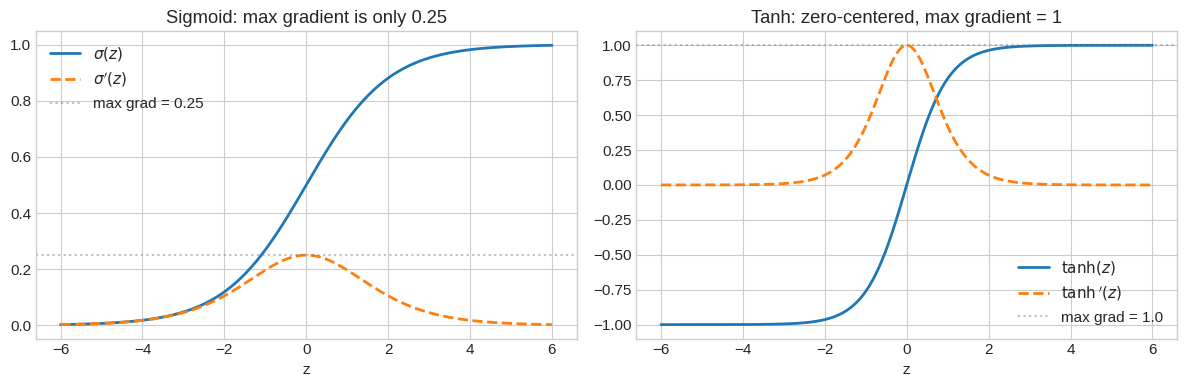

In [ ]:
# Visualize saturation: gradient magnitude drops to near-zero for large |z|
z = torch.linspace(-6, 6, 500)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Sigmoid
axes[0].plot(z.numpy(), sigmoid_forward(z).numpy(), label="$\\sigma(z)$", linewidth=2)
axes[0].plot(z.numpy(), sigmoid_backward(z).numpy(), label="$\\sigma'(z)$", linewidth=2, linestyle="--")
axes[0].axhline(y=0.25, color="gray", linestyle=":", alpha=0.5, label="max grad = 0.25")
axes[0].set_title("Sigmoid: max gradient is only 0.25")
axes[0].legend()
axes[0].set_xlabel("z")

# Tanh
axes[1].plot(z.numpy(), tanh_forward(z).numpy(), label="$\\tanh(z)$", linewidth=2)
axes[1].plot(z.numpy(), tanh_backward(z).numpy(), label="$\\tanh'(z)$", linewidth=2, linestyle="--")
axes[1].axhline(y=1.0, color="gray", linestyle=":", alpha=0.5, label="max grad = 1.0")
axes[1].set_title("Tanh: zero-centered, max gradient = 1")
axes[1].legend()
axes[1].set_xlabel("z")

plt.tight_layout()
plt.show()

## 1.3 ReLU (Derivation, Forward/Backward, Dying ReLU)

$$\text{ReLU}(z) = \max(0, z)$$

$$\text{ReLU}'(z) = \begin{cases} 1 & \text{if } z > 0 \\ 0 & \text{if } z < 0 \end{cases}$$

**Why ReLU dominates:**
1. No saturation in the positive regime (gradient is exactly 1)
2. Computationally trivial (comparison + mask)
3. Promotes sparsity (~50% of neurons output zero)

**Dying ReLU Problem:** If $z < 0$ for all inputs in a mini-batch, the gradient is zero. With SGD updates, the neuron can get permanently stuck at zero output ("dead neuron"). Once $W$ shifts so that $Wx + b < 0 \ \forall x$, no gradient flows back, and the neuron never recovers.

In [ ]:
def relu_forward(z: torch.Tensor) -> torch.Tensor:
    # (*, ) -> (*, )
    return torch.clamp(z, min=0.0)


def relu_backward(z: torch.Tensor) -> torch.Tensor:
    # (*, ) -> (*, )
    return (z > 0).float()


# Demonstrate dying ReLU: once biases shift negative enough, neurons die
num_samples, hidden_dim = 1000, 256

# Simulate a layer with large negative bias
# (num_samples, hidden_dim)
z_pre = torch.randn(num_samples, hidden_dim) - 3.0

# (num_samples, hidden_dim)
activated = relu_forward(z_pre)

fraction_dead = (activated.sum(dim=0) == 0).float().mean().item()
print(f"Fraction of dead neurons (bias=-3): {fraction_dead:.1%}")
print(f"These neurons will NEVER receive gradient updates.")

Fraction of dead neurons (bias=-3): 27.0%
These neurons will NEVER receive gradient updates.


## 1.4 Leaky ReLU & Parametric ReLU

![](https://miro.medium.com/v2/resize:fit:1400/1*ypsvQH7kvtI2BhzR2eT_Sw.png)

**Leaky ReLU** addresses dying neurons by allowing a small gradient when $z < 0$:

$$\text{LeakyReLU}(z) = \begin{cases} z & \text{if } z > 0 \\ \alpha z & \text{if } z \leq 0 \end{cases}$$

where $\alpha$ is a small constant (typically 0.01).

$$\text{LeakyReLU}'(z) = \begin{cases} 1 & \text{if } z > 0 \\ \alpha & \text{if } z \leq 0 \end{cases}$$

**Parametric ReLU (PReLU):** Same form, but $\alpha$ is a **learnable parameter** updated via backpropagation:

$$\frac{\partial L}{\partial \alpha} = \sum_{z_i < 0} z_i \cdot \frac{\partial L}{\partial \text{PReLU}(z_i)}$$

In [ ]:
def leaky_relu_forward(z: torch.Tensor, alpha: float = 0.01) -> torch.Tensor:
    # (*, ) -> (*, )
    return torch.where(z > 0, z, alpha * z)


def leaky_relu_backward(z: torch.Tensor, alpha: float = 0.01) -> torch.Tensor:
    # (*, ) -> (*, )
    return torch.where(z > 0, torch.ones_like(z), alpha * torch.ones_like(z))


def prelu_forward(z: torch.Tensor, alpha: torch.Tensor) -> torch.Tensor:
    """PReLU: alpha is a learnable parameter (scalar or per-channel)."""
    # (*, ) -> (*, )
    return torch.where(z > 0, z, alpha * z)


def prelu_backward_z(z: torch.Tensor, alpha: torch.Tensor) -> torch.Tensor:
    """Gradient w.r.t. input z."""
    # (*, ) -> (*, )
    return torch.where(z > 0, torch.ones_like(z), alpha.expand_as(z))


def prelu_backward_alpha(z: torch.Tensor, grad_output: torch.Tensor) -> torch.Tensor:
    """Gradient w.r.t. learnable alpha: sum over negative activations."""
    # (*, ) -> scalar
    return (torch.where(z > 0, torch.zeros_like(z), z) * grad_output).sum()


# Verify: leaky ReLU has no dead neurons
z_pre = torch.randn(1000, 256) - 3.0
activated_leaky = leaky_relu_forward(z_pre)
fraction_dead_leaky = (activated_leaky.sum(dim=0) == 0).float().mean().item()
print(f"Dead neurons with LeakyReLU: {fraction_dead_leaky:.1%} (vs ReLU: many dead)")

Dead neurons with LeakyReLU: 0.0% (vs ReLU: many dead)


## 1.5 GELU (Gaussian Error Linear Unit)

GELU combines the gating mechanism of dropout with the deterministic nature of an activation. It stochastically zeros or preserves inputs based on their magnitude, but in **expectation**.

A neuron's input $z$ is multiplied by a Bernoulli mask $m \sim \text{Bernoulli}(\Phi(z))$ where $\Phi$ is the standard Gaussian CDF. The expected output is:

$$\text{GELU}(z) = z \cdot \Phi(z) = z \cdot \frac{1}{2}\left[1 + \text{erf}\left(\frac{z}{\sqrt{2}}\right)\right]$$

**Derivative:**
$$\text{GELU}'(z) = \Phi(z) + z \cdot \phi(z)$$

where $\phi(z) = \frac{1}{\sqrt{2\pi}}e^{-z^2/2}$ is the Gaussian PDF.

**Tanh approximation** (used in GPT-2, BERT):
$$\text{GELU}(z) \approx 0.5 z \left[1 + \tanh\left(\sqrt{\frac{2}{\pi}}(z + 0.044715 z^3)\right)\right]$$

**Why it works:** Large positive inputs are preserved; large negative inputs are suppressed; near-zero inputs get a smooth, probabilistic gate. This is smoother than ReLU's hard threshold.

In [ ]:
def gelu_forward_exact(z: torch.Tensor) -> torch.Tensor:
    """Exact GELU using the error function."""
    # (*, ) -> (*, )
    return 0.5 * z * (1.0 + torch.erf(z / np.sqrt(2.0)))


def gelu_forward_approx(z: torch.Tensor) -> torch.Tensor:
    """Tanh approximation of GELU (as used in GPT-2)."""
    # (*, ) -> (*, )
    return 0.5 * z * (1.0 + torch.tanh(np.sqrt(2.0 / np.pi) * (z + 0.044715 * z ** 3)))


def gelu_backward_exact(z: torch.Tensor) -> torch.Tensor:
    """Derivative: Phi(z) + z * phi(z)."""
    # (*, ) -> (*, )
    cdf = 0.5 * (1.0 + torch.erf(z / np.sqrt(2.0)))
    pdf = torch.exp(-0.5 * z ** 2) / np.sqrt(2.0 * np.pi)
    return cdf + z * pdf


# Verify approximation quality
z_test = torch.linspace(-4, 4, 1000)
max_approx_err = (gelu_forward_exact(z_test) - gelu_forward_approx(z_test)).abs().max().item()
print(f"Max error between exact and tanh-approx GELU: {max_approx_err:.6f}")

Max error between exact and tanh-approx GELU: 0.000473


## 1.6 SiLU / Swish (Self-Gated Activation)

![](https://miro.medium.com/v2/resize:fit:794/0*zzwSGGzn8ZhSsLFN)

**Definition:**
$$\text{SiLU}(z) = z \cdot \sigma(z) = \frac{z}{1 + e^{-z}}$$

**Derivative:**
$$\text{SiLU}'(z) = \sigma(z) + z \cdot \sigma(z)(1 - \sigma(z)) = \sigma(z)(1 + z(1 - \sigma(z)))$$

**Key insight:** The input $z$ acts as its own gate via $\sigma(z)$. This "self-gating" mechanism:
- For large positive $z$: $\sigma(z) \approx 1$, so $\text{SiLU}(z) \approx z$ (identity-like)
- For large negative $z$: $\sigma(z) \approx 0$, so $\text{SiLU}(z) \approx 0$ (ReLU-like suppression)
- Near zero: smooth, nonlinear transition

**Non-monotonicity:** SiLU has a small dip below zero near $z \approx -1.28$, which empirically acts as an implicit regularizer.

**Why it outperforms ReLU:** Discovered via neural architecture search (Ramachandran et al., 2017). The smooth, non-monotonic shape provides better gradient flow and implicit regularization. Used in EfficientNet, modern diffusion models.

In [ ]:
def silu_forward(z: torch.Tensor) -> torch.Tensor:
    # (*, ) -> (*, )
    sig = sigmoid_forward(z)
    return z * sig


def silu_backward(z: torch.Tensor) -> torch.Tensor:
    """Derivative: sigma(z) * (1 + z * (1 - sigma(z)))."""
    # (*, ) -> (*, )
    sig = sigmoid_forward(z)
    return sig * (1.0 + z * (1.0 - sig))


# Show the non-monotonic dip
z = torch.linspace(-6, 6, 500)
y = silu_forward(z)
min_val, min_idx = y.min(), y.argmin()
print(f"SiLU minimum: {min_val.item():.4f} at z = {z[min_idx].item():.2f}")
print("This non-monotonic dip acts as an implicit regularizer.")

SiLU minimum: -0.2785 at z = -1.29
This non-monotonic dip acts as an implicit regularizer.


## 1.7 Mish (Smooth Non-Monotonic Activation)

**Definition:**
$$\text{Mish}(z) = z \cdot \tanh(\text{softplus}(z)) = z \cdot \tanh(\ln(1 + e^z))$$

**Derivative:**
Let $\omega = 4(z + 1) + 4e^{2z} + e^{3z} + e^z(4z + 6)$ and $\delta = (2e^z + e^{2z} + 2)^2$.

$$\text{Mish}'(z) = \frac{e^z \cdot \omega}{\delta}$$

In practice, we use the chain rule form:

$$\text{Mish}'(z) = \frac{e^z \cdot \text{sech}^2(\text{softplus}(z))}{1 + e^z} \cdot z + \tanh(\text{softplus}(z))$$

**Properties:**
- Smooth (infinitely differentiable, unlike ReLU)
- Non-monotonic (like SiLU) — dips slightly below zero
- Self-regularizing through the nonlinear gating
- Unbounded above, bounded below
- Used in YOLOv4, various vision models

In [ ]:
def softplus(z: torch.Tensor) -> torch.Tensor:
    """Numerically stable softplus: log(1 + exp(z))."""
    # (*, ) -> (*, )
    return torch.where(z > 20, z, torch.log1p(torch.exp(z)))


def mish_forward(z: torch.Tensor) -> torch.Tensor:
    # (*, ) -> (*, )
    return z * torch.tanh(softplus(z))


def mish_backward(z: torch.Tensor) -> torch.Tensor:
    """Derivative via chain rule: d/dz [z * tanh(softplus(z))]."""
    # (*, ) -> (*, )
    sp = softplus(z)
    tanh_sp = torch.tanh(sp)
    sech2_sp = 1.0 - tanh_sp ** 2
    sigmoid_z = sigmoid_forward(z)
    return tanh_sp + z * sech2_sp * sigmoid_z


# Verify with autograd
z_test = torch.randn(100, requires_grad=True)
out = mish_forward(z_test).sum()
out.backward()

z_no_grad = z_test.detach()
manual_grad = mish_backward(z_no_grad)
print(f"Mish gradient max error vs autograd: {(z_test.grad - manual_grad).abs().max().item():.2e}")

Mish gradient max error vs autograd: 1.19e-07


## 1.8 Comparison

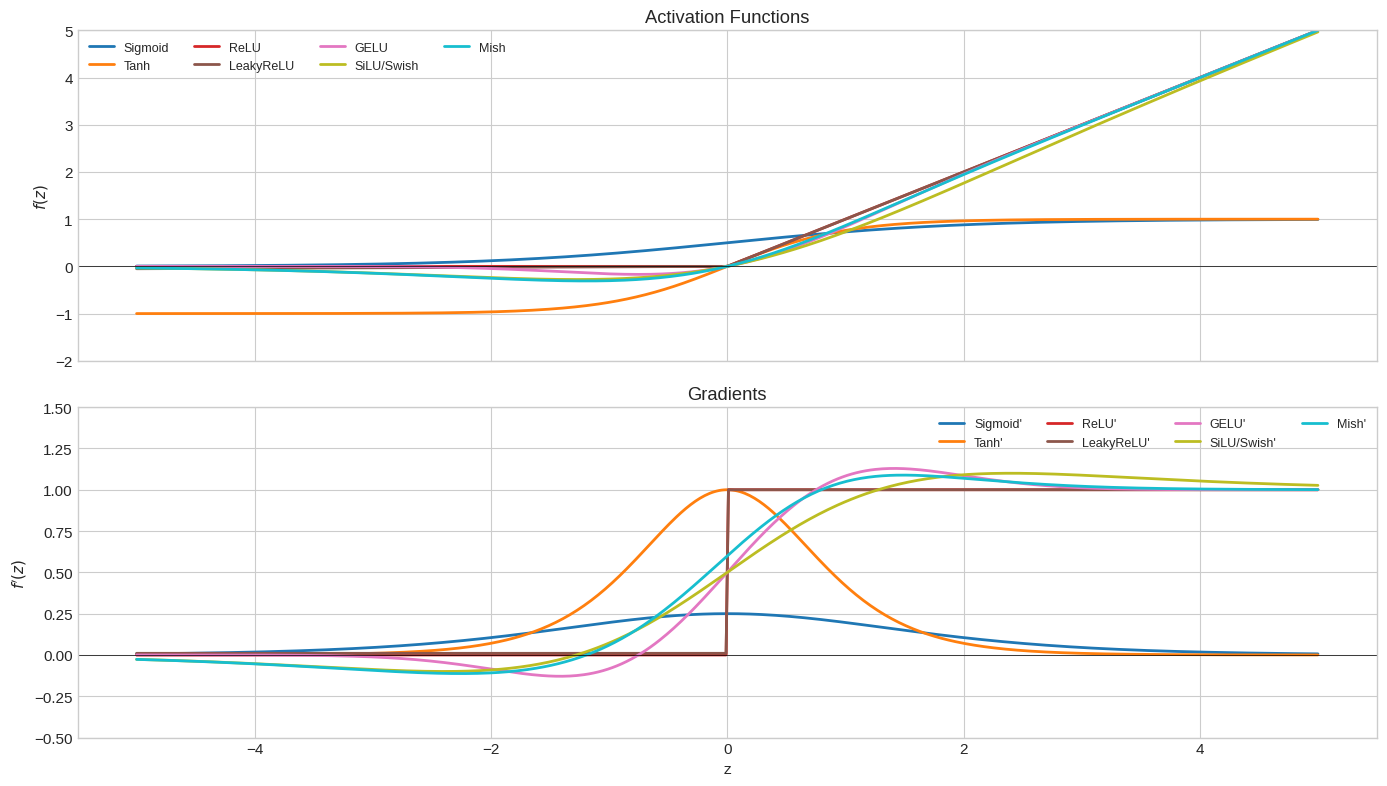

In [ ]:
z = torch.linspace(-5, 5, 500)

activations = {
    "Sigmoid": (sigmoid_forward, sigmoid_backward),
    "Tanh": (tanh_forward, tanh_backward),
    "ReLU": (relu_forward, relu_backward),
    "LeakyReLU": (leaky_relu_forward, leaky_relu_backward),
    "GELU": (gelu_forward_exact, gelu_backward_exact),
    "SiLU/Swish": (silu_forward, silu_backward),
    "Mish": (mish_forward, mish_backward),
}

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
colors = plt.cm.tab10(np.linspace(0, 1, len(activations)))

for (name, (fwd, bwd)), color in zip(activations.items(), colors):
    y = fwd(z).numpy()
    dy = bwd(z).numpy()
    axes[0].plot(z.numpy(), y, label=name, color=color, linewidth=2)
    axes[1].plot(z.numpy(), dy, label=f"{name}'", color=color, linewidth=2)

axes[0].set_title("Activation Functions")
axes[0].set_ylabel("$f(z)$")
axes[0].legend(ncol=4, fontsize=9)
axes[0].axhline(y=0, color="black", linewidth=0.5)
axes[0].set_ylim(-2, 5)

axes[1].set_title("Gradients")
axes[1].set_ylabel("$f'(z)$")
axes[1].set_xlabel("z")
axes[1].legend(ncol=4, fontsize=9)
axes[1].axhline(y=0, color="black", linewidth=0.5)
axes[1].set_ylim(-0.5, 1.5)

plt.tight_layout()
plt.show()

**When to Use Which**

| Activation | Best For | Avoid When | Notes |
|-----------|----------|------------|-------|
| **ReLU** | Default choice, CNNs, fast prototyping | Very deep networks with aggressive learning rates (dying neurons) | Simplest, fastest |
| **Leaky ReLU** | When ReLU neurons die | — | Minimal overhead vs ReLU |
| **GELU** | Transformers (BERT, GPT, ViT) | Latency-critical inference | Smooth, probabilistic gating |
| **SiLU/Swish** | Modern CNNs (EfficientNet), diffusion models | — | Found via NAS |
| **Mish** | Object detection (YOLOv4) | Memory-constrained (stores more for backward) | Smooth, non-monotonic |
| **Sigmoid** | Output layer for binary classification | Hidden layers (vanishing gradient) | Range $(0,1)$ |
| **Tanh** | Output layer for $[-1,1]$ range, RNNs | Deep hidden layers (still saturates) | Zero-centered |

**Rule of thumb for 2024+:** GELU for Transformers, SiLU for CNNs/diffusion, ReLU as baseline.

---
# Summary

- Nonlinearity is essential (linear composition collapse)
- ReLU is the default; GELU for Transformers; SiLU for modern CNNs
- The activation function determines the correct initialization scheme